In [40]:
# ====================================================================================
# Install SQL libraries using PowerShell:
#   pip install sqlalchemy
#   pip install sqlalchemy pg8000
# SQLAlchemy: Python library for database access and ORM (Object Relational Mapping).
# PG8000: Pure-Python driver for connecting to PostgreSQL databases.
# ====================================================================================

# Libraries
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import create_engine

In [5]:
# PostgreSQL connection details
username = 'postgres'
password = 'admin'
host = 'localhost'
port = '5432'
database = 'analytics_db'

# Create connection using create_engine (which acts as 
# the main interface between Python code and the database)
engine = create_engine(
    f'postgresql+pg8000://{username}:{password}@{host}:{port}/{database}'
    )

In [6]:
# Fetch the data from PostgreSQL analytics_db server - gold layer
df_raw = pd.read_sql(
    'SELECT * ' \
    'FROM gold.weather_observations',
    con=engine 
    # con=engine in pd.read_sql() tells pandas which 
    # database connection to use when executing the SQL query
)

### Inspect df

In [8]:
df_raw.head()

,station,station_name,elevation,observation_date,month_year,metric,value
0,PL000012120,Leba,2.0,2021-02-14,02-2021,TMAX,2.7
1,PL000012120,Leba,2.0,2021-02-14,02-2021,TMIN,0.1
2,PL000012120,Leba,2.0,2021-02-14,02-2021,PRCP,0.0
3,PL000012120,Leba,2.0,2021-02-14,02-2021,SNWD,351.0
4,PL000012120,Leba,2.0,2021-02-14,02-2021,TAVG,1.1


In [20]:
df_raw['metric'].unique()

<StringArray>
['TMAX', 'TMIN', 'PRCP', 'SNWD', 'TAVG']
Length: 5, dtype: str

In [10]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 125039 entries, 0 to 125038
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   station           125039 non-null  str    
 1   station_name      125039 non-null  str    
 2   elevation         125039 non-null  float64
 3   observation_date  125039 non-null  object 
 4   month_year        125039 non-null  str    
 5   metric            125039 non-null  str    
 6   value             125039 non-null  float64
dtypes: float64(2), object(1), str(4)
memory usage: 6.7+ MB


In [18]:
# Convert observation_date to date
df = df_raw.copy()
df['observation_date'] = pd.to_datetime(df['observation_date'])

In [19]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 125039 entries, 0 to 125038
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype        
---  ------            --------------   -----        
 0   station           125039 non-null  str          
 1   station_name      125039 non-null  str          
 2   elevation         125039 non-null  float64      
 3   observation_date  125039 non-null  datetime64[s]
 4   month_year        125039 non-null  str          
 5   metric            125039 non-null  str          
 6   value             125039 non-null  float64      
dtypes: datetime64[s](1), float64(2), str(4)
memory usage: 6.7 MB


In [11]:
df_raw.isna().sum()

station             0
station_name        0
elevation           0
observation_date    0
month_year          0
metric              0
value               0
dtype: int64

In [12]:
df_raw["metric"].value_counts()

metric
TAVG    36892
PRCP    32877
TMAX    30561
TMIN    20972
SNWD     3737
Name: count, dtype: int64

In [13]:
df_raw["observation_date"].min(), df_raw["observation_date"].max()

(datetime.date(2016, 1, 1), datetime.date(2026, 6, 29))

### Analyze the trend in Poland's average annual temperature

In [ ]:
# FIlter out TAVG metric only
avg_temp_raw = df.copy()
avg_temp = avg_temp_raw[avg_temp_raw['metric'] == 'TAVG']

avg_temp

,station,station_name,elevation,observation_date,month_year,metric,value
4,PL000012120,Leba,2.0,2021-02-14,02-2021,TAVG,1.1
9,PL000012385,Siedlce,152.0,2021-02-14,02-2021,TAVG,-2.1
13,PLM00012160,Elblag-Milejewo,43.0,2021-02-14,02-2021,TAVG,-0.4
16,PLM00012205,Szczecin,7.0,2021-02-14,02-2021,TAVG,-5.4
20,PLM00012295,Bialystok,151.0,2021-02-14,02-2021,TAVG,-1.0
...,...,...,...,...,...,...,...
125029,PLM00012330,Lawica,93.9,2021-02-13,02-2021,TAVG,-2.4
125031,PLM00012375,Okecie,110.3,2021-02-13,02-2021,TAVG,-1.6
125034,PLM00012424,Strachowice,123.1,2021-02-13,02-2021,TAVG,-3.8
125036,PLM00012497,Wlodawa,179.0,2021-02-13,02-2021,TAVG,-3.9


In [28]:
# Extract year from observation_date
avg_temp['year'] = avg_temp['observation_date'].dt.year

# Group by year
avg_temp_agg = avg_temp.groupby(['year']).agg(
    avg_temp=('value', 'mean'))

avg_temp_agg

,avg_temp
year,
2016,9.134836
2017,8.934329
2018,9.814458
2019,10.193918
2020,9.957186
2021,8.745950
2022,9.486466
2023,10.047918
2024,10.950225


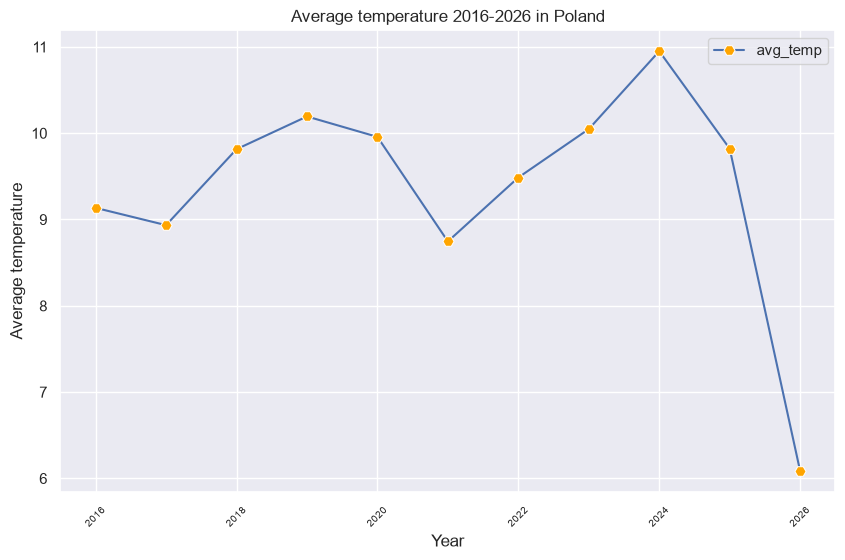

In [ ]:
# Add a grid in the background
sns.set_theme(style="darkgrid")  

# Set figure size
plt.figure(figsize=(10, 6))  

sns.lineplot(
    data=avg_temp_agg,
    marker='H',
    markersize=8,
    markerfacecolor='orange',
    color='purple'
    )

plt.title("Average temperature in Poland (2015-2025)") # Title
plt.xlabel("Year") # x-axis name
plt.ylabel("Average temperature") # y-axis name

# Rotate x-axis labels to 45 degrees and reduce labels size
plt.xticks(rotation=45, fontsize=7)

# Display the plot
plt.show() 